# ML9_Convolutional_networks

## 0. Imports

In [81]:
!pip install -q imagehash torchmetrics albumentations

In [82]:
import hashlib
import os
import shutil
import subprocess
import time
import warnings
import zipfile

import albumentations as A
import cv2
import imagehash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import timm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchmetrics.classification import MulticlassAUROC
import torchvision.transforms as transforms
from tqdm import tqdm

from albumentations.pytorch import ToTensorV2

## help functions

In [83]:
# чтобы обучать модель на GPU, 
# нужен эффективный по памяти формат загружаемых данных - например, .npy
def pack_dataset(df, image_dir, out_prefix, transform):
    unique_labels = sorted(df['Label'].unique())
    label_to_idx = {lbl: i for i, lbl in enumerate(unique_labels)}

    images, labels = [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        path = row['img_path']
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = transform(img)
        images.append(img_tensor.numpy())
        labels.append(label_to_idx[row['Label']])

    np.save(f'{out_prefix}_images.npy', np.array(images, dtype=np.float32))
    np.save(f'{out_prefix}_labels.npy', np.array(labels, dtype=np.int64))

In [84]:
class NpyDataset(Dataset):
    def __init__(self, images_file, labels_file):
        self.images = np.load(images_file, mmap_mode='r')
        self.labels = np.load(labels_file)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx].copy())
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

In [85]:
# создаем датасеты - v1 - через класс NpyDataset () распаковывает .npy файлы
def create_datasets_v1():
    train_dataset = NpyDataset('train_images.npy', 'train_labels.npy')
    valid_dataset = NpyDataset('valid_images.npy', 'valid_labels.npy')
    
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,
                              num_workers=4, pin_memory=True)
    valid_loader = DataLoader(valid_dataset, batch_size=256, shuffle=False,
                              num_workers=4, pin_memory=True)
    return train_loader, valid_loader

In [86]:
def check_input(train_loader, valid_loader):
    images, labels = next(iter(train_loader))
    print(f"Train: images{images.shape}, labels:{labels.shape}")
    print(f"dtype: {images.dtype}, min: {images.min():.3f}, max: {images.max():.3f}")

    images, labels = next(iter(valid_loader))
    print(f"Valid: images{images.shape}, labels:{labels.shape}")
    print(f"dtype: {images.dtype}, min: {images.min():.3f}, max: {images.max():.3f}")

In [87]:
def initialize_model(model, num_classes = 9):
    loss_func = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)
    
    auroc = MulticlassAUROC(num_classes=num_classes, average='macro') # 'weighted'
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    #print("CUDA доступна:", torch.cuda.is_available())
    #print("Имя GPU:", torch.cuda.get_device_name(0))

    return loss_func, optimizer, auroc, device

In [88]:
# пакует в сырой npy формат без трансформаций
# нужно для использования аугментаций из albumentations
def pack_dataset_raw(df, image_dir, out_prefix, target_size):
    unique_labels = sorted(df['Label'].unique())
    label_to_idx = {lbl: i for i, lbl in enumerate(unique_labels)}

    images, labels = [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        path = os.path.join(image_dir, row['img_IDS'] + '.jpg')
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, target_size)          # (H,W,3) uint8
        images.append(img)
        labels.append(label_to_idx[row['Label']])

    np.save(f'{out_prefix}_images_raw.npy', np.array(images, dtype=np.uint8))
    np.save(f'{out_prefix}_labels.npy', np.array(labels, dtype=np.int64))

In [89]:
# применяет albumentations в формате transform
class RawNpyDataset(Dataset):
    def __init__(self, images_file, labels_file, transform=None):
        self.images = np.load(images_file, mmap_mode='r')   # (N,H,W,3) uint8
        self.labels = np.load(labels_file)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx].copy()
        label = self.labels[idx]
        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']           #(C,H,W)
            if isinstance(img, np.ndarray):
                img = torch.from_numpy(img.transpose(2,0,1)).float() / 255.0
            elif img.dtype == torch.uint8:
                img = img.float() / 255.0
        else:
            img = torch.from_numpy(img.transpose(2,0,1)).float() / 255.0
        label = torch.tensor(label, dtype=torch.long)
        return img, label

In [90]:
# создаем датасеты - v2 - через класс RawNpyDataset () распаковывает .npy файлы
# позволяет сначала применить трансформации из albumentations, затем привести к тензорам
def create_datasets_v2(train_transform=None, valid_transform=None):
    train_dataset = RawNpyDataset('train_images_raw.npy', 'train_labels.npy',train_transform)
    valid_dataset = RawNpyDataset('valid_images_raw.npy', 'valid_labels.npy',valid_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,
                              num_workers=4, pin_memory=True)
    valid_loader = DataLoader(valid_dataset, batch_size=256, shuffle=False,
                              num_workers=4, pin_memory=True)
    return train_loader, valid_loader

In [ ]:
def train_validation_loop_old(model, train_loader, valid_loader, loss_func, optimizer, 
                          auroc, device, model_name:str, max_epochs=100, 
                          mixup=False, cutmix=False, alpha1=1.0, alpha2=1.0):
  model.to(device)
  auroc = auroc.to(device)
  maxauc = 0
  target_auc = 0.9
  epochs_no_improve = 0
  patience = 5
  min_delta=1e-3

  for epoch in range(max_epochs):
    #start = time.time()
    model.train()
    for itr, data in enumerate(train_loader):
      imgs = data[0].to(device) # 100, 3, 32, 32
      labels = data[1].to(device)

      if mixup==True:
          mixed_imgs, (lam, labels_a, labels_b) = MyMixUP(imgs, labels, alpha1)
          y_pred = model(mixed_imgs)
          loss = lam * loss_func(y_pred, labels_a) + (1 - lam) * loss_func(y_pred, labels_b)
      elif cutmix==True:
          mixed_imgs, (lam, labels_a, labels_b) = MyCutMix(imgs, labels, alpha2)
          y_pred = model(mixed_imgs)
          loss = lam * loss_func(y_pred, labels_a) + (1 - lam) * loss_func(y_pred, labels_b)
      else:
          y_pred = model(imgs)
          loss = loss_func(y_pred, labels)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
        
      #if itr%20 == 0:
      #   print(f"Iteration {itr}, loss {loss:.4f}")

    model.eval()
    with torch.no_grad():
      for x, y in valid_loader:
        x = x.to(device)
        y = y.to(device)
        preds = torch.softmax(model(x), dim=1)
        auroc.update(preds, y)


    final_auc = auroc.compute()
    #print(f"Validation AUC: {final_auc}")
    auroc.reset()
      
    if final_auc > maxauc + min_delta:
            maxauc = final_auc
            torch.save(model.state_dict(), f'best_model_{model_name}.pth')
            print(f"New best model saved with AUC: {maxauc:.4f}")
            epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    #epoch_time = time.time() - start
    #print(f"Эпоха {epoch+1} заняла {epoch_time:.2f} сек")

    if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

    if final_auc > target_auc:
        print(f"Target AUC {target_auc} reached. Stopping training.")
        break
  return maxauc

In [91]:
def train_validation_loop(
        model, train_loader, valid_loader, loss_func, optimizer,
        auroc, device, model_name: str, max_epochs=100,
        mixup=False, cutmix=False,
        alpha_mixup=1.0, alpha_cutmix=1.0,
        tta_flip=False, tta_loader=None,
        target_auc=0.9, patience=5, min_delta=1e-3):

    model.to(device)
    auroc = auroc.to(device)
    maxauc = 0
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        for itr, data in enumerate(train_loader):
            imgs = data[0].to(device)
            labels = data[1].to(device)

            if mixup:
                mixed_imgs, (lam, labels_a, labels_b) = MyMixUP(imgs, labels, alpha_mixup)
                outputs = model(mixed_imgs)
                loss = lam * loss_func(outputs, labels_a) + (1 - lam) * loss_func(outputs, labels_b)
            elif cutmix:
                mixed_imgs, (lam, labels_a, labels_b) = MyCutMix(imgs, labels, alpha_cutmix)
                outputs = model(mixed_imgs)
                loss = lam * loss_func(outputs, labels_a) + (1 - lam) * loss_func(outputs, labels_b)
            else:
                outputs = model(imgs)
                loss = loss_func(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            if tta_loader is not None:
                for (x_orig, y), (x_aug, _) in zip(valid_loader, tta_loader):
                    x_orig = x_orig.to(device)
                    x_aug = x_aug.to(device)
                    y = y.to(device)

                    preds_orig = torch.softmax(model(x_orig), dim=1)
                    preds_aug = torch.softmax(model(x_aug), dim=1)
                    preds_avg = (preds_orig + preds_aug) / 2

                    auroc.update(preds_avg, y)
            elif tta_flip:
                # TTA с горизонтальным отражением
                for x, y in valid_loader:
                    x = x.to(device)
                    y = y.to(device)

                    preds_orig = torch.softmax(model(x), dim=1)
                    x_flipped = torch.flip(x, dims=[3])  # NCHW -> отражение по ширине
                    preds_flipped = torch.softmax(model(x_flipped), dim=1)
                    preds_avg = (preds_orig + preds_flipped) / 2

                    auroc.update(preds_avg, y)
            else:

                for x, y in valid_loader:
                    x = x.to(device)
                    y = y.to(device)
                    preds = torch.softmax(model(x), dim=1)
                    auroc.update(preds, y)

        final_auc = auroc.compute()
        #print(f"Эпоха {epoch+1}, Validation AUC: {final_auc:.4f}")
        auroc.reset()

        if final_auc > maxauc + min_delta:
            maxauc = final_auc
            torch.save(model.state_dict(), f'best_model_{model_name}.pth')
            print(f"Новая лучшая модель сохранена с AUC: {maxauc:.4f}")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Ранняя остановка на эпохе {epoch+1}")
            break

        if final_auc >= target_auc:
            print(f"Достигнут целевой AUC {target_auc}. Обучение остановлено.")
            break

    return maxauc

## 1. Download the Zindi gesture data.
- Examine the data for some time. Make sure you get rid of duplicate examples. Are there any mislabeled examples?

In [92]:
!gdown 1ZgCpw19Y30RNtNyqCebTxgQDhVx9HSoD # train.csv

Downloading...
From: https://drive.google.com/uc?id=1ZgCpw19Y30RNtNyqCebTxgQDhVx9HSoD
To: /kaggle/working/Train.csv
100%|████████████████████████████████████████| 149k/149k [00:00<00:00, 75.2MB/s]


In [93]:
train_data = pd.read_csv("Train.csv")
train_data

,img_IDS,Label
0,ImageID_33HMDMJ3,Temple
1,ImageID_V5POEX4O,Church
2,ImageID_89CCCCW6,Enough/Satisfied
3,ImageID_GNJXOWX5,Me
4,ImageID_7Q9LOP7R,Love
...,...,...
6244,ImageID_F2HTAA5P,Love
6245,ImageID_0D69ZQ4X,Church
6246,ImageID_E67IZXVJ,Seat
6247,ImageID_ENGL8NP3,You


In [94]:
!gdown 14iUqTrz_jRuujncNkG49rxEWqN-On8YZ #Images.zip

Downloading...
From (original): https://drive.google.com/uc?id=14iUqTrz_jRuujncNkG49rxEWqN-On8YZ
From (redirected): https://drive.google.com/uc?id=14iUqTrz_jRuujncNkG49rxEWqN-On8YZ&confirm=t&uuid=66509db8-e531-4ee9-a8ed-020fb2e70cc6
To: /kaggle/working/Images.zip
100%|███████████████████████████████████████| 1.18G/1.18G [00:09<00:00, 123MB/s]


In [95]:
extract_path = "/kaggle/working/Images.zip"
data_path = "/kaggle/working/data"

os.makedirs(data_path, exist_ok=True)
with zipfile.ZipFile(extract_path, "r") as zf:
  zf.extractall(data_path)
os.remove(extract_path)

In [96]:
folder = '/kaggle/working/data/Images'
extensions = ('.jpg')
count = sum(1 for f in os.listdir(folder) if f.lower().endswith(extensions))
print(f'Количество изображений: {count}')

Количество изображений: 8928


In [97]:
# изображений больше чем в датасете, чистим
valid_ids = set(train_data['img_IDS'].astype(str).str.strip())
all_files = os.listdir(folder)
for filename in all_files:
  if filename.lower().endswith(('.jpg')):
    file_id = os.path.splitext(filename)[0]
    if file_id not in valid_ids:
            file_path = os.path.join(folder, filename)
            os.remove(file_path)

In [98]:
extensions = ('.jpg')
count = sum(1 for f in os.listdir(folder) if f.lower().endswith(extensions))
print(f'Количество изображений: {count}')

# вычисляем хэш, чтобы найти точные дубликаты и предполагаемые 
# (с порогом Hamming distance  - сколько битов отличаются)
def file_hash(filepath):
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []
image_dir = folder
for img_file in os.listdir(image_dir):
    path = os.path.join(image_dir, img_file)
    h = file_hash(path)
    if h in hashes:
        duplicates.append((img_file, hashes[h]))
    else:
        hashes[h] = img_file

print("Duplicate pairs:", duplicates)

Количество изображений: 6249
Duplicate pairs: []


In [20]:
# ищем около-дубликаты по порогу
hash_dict = {}
duplicates_near = []
threshold = 5  # Hamming distance

for img_file in os.listdir(image_dir):
    path = os.path.join(image_dir, img_file)
    img = Image.open(path)
    phash = imagehash.phash(img)

    for existing_hash, existing_file in hash_dict.items():
        if phash - existing_hash <= threshold:
            duplicates_near.append((img_file, existing_file))
            break
    else:
        hash_dict[phash] = img_file

print("Near‑duplicate pairs:", duplicates_near)

Near‑duplicate pairs: [('ImageID_ONZG1KH6.jpg', 'ImageID_WA59WTSP.jpg'), ('ImageID_GL5IYQGL.jpg', 'ImageID_P46G9TG1.jpg')]


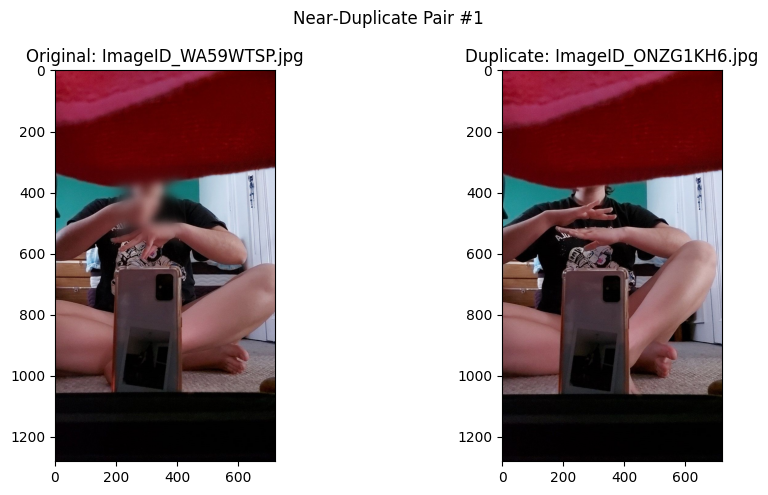

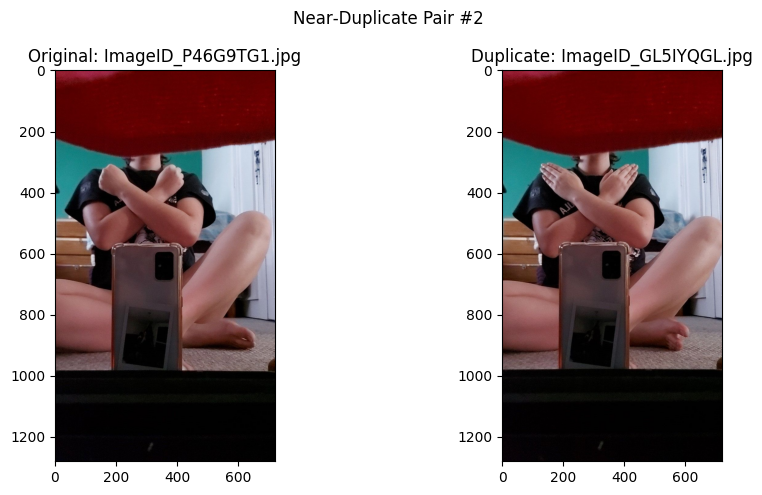

In [21]:
num_pairs_to_show = len(duplicates_near)

for i, (dup_file, orig_file) in enumerate(duplicates_near[:num_pairs_to_show]):
    dup_path = os.path.join(image_dir, dup_file)
    orig_path = os.path.join(image_dir, orig_file)

    dup_img = Image.open(dup_path)
    orig_img = Image.open(orig_path)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(orig_img)
    axes[0].set_title(f"Original: {orig_file}")

    axes[1].imshow(dup_img)
    axes[1].set_title(f"Duplicate: {dup_file}")

    plt.suptitle(f"Near‑Duplicate Pair #{i+1}")
    plt.tight_layout()
    plt.show()

- Видно, что это не дубликаты - значит таковых нет.

- Think about which extensions would be optimal for the current task. Design a training and validation split.
- Use a random 33% of the total data as the validation set.

In [99]:
# random split
base_path = '/kaggle/working/data/Images'
train_data['img_path'] = train_data['img_IDS'].apply(lambda x: os.path.join(base_path, x + '.jpg'))

train_df, valid_df = train_test_split(train_data,test_size=0.33,
                                      stratify=train_data['Label'],
                                      random_state=21)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

In [23]:
train_df.nunique()

img_IDS     4186
Label          9
img_path    4186
dtype: int64

In [24]:
print(train_df.shape)
valid_df.shape

(4186, 3)


(2063, 3)

In [25]:
valid_df.head()

,img_IDS,Label,img_path
0,ImageID_2EPXC5DP,Me,/kaggle/working/data/Images/ImageID_2EPXC5DP.jpg
1,ImageID_48ZYUOIR,Temple,/kaggle/working/data/Images/ImageID_48ZYUOIR.jpg
2,ImageID_1XXG2QD8,Seat,/kaggle/working/data/Images/ImageID_1XXG2QD8.jpg
3,ImageID_6HZFDRVG,Friend,/kaggle/working/data/Images/ImageID_6HZFDRVG.jpg
4,ImageID_QF99JJMU,Seat,/kaggle/working/data/Images/ImageID_QF99JJMU.jpg


## 2. Write a custom pytorch dataset class for image and goal retrieval:
- read images using OpenCV2, extract targets using pandas.
- Make sure the dataset class has the correct API for sample retrieval.
- Create a pytorch DataLoader for your datasets.

In [26]:
transform = transforms.Compose([
    transforms.ToPILImage(), # np > PIL
    transforms.Resize((32, 32)), # resize ожидает на вход PIL
    transforms.ToTensor(),
])

In [27]:
image_dir = '/kaggle/working/data/Images'
pack_dataset(train_df, image_dir, 'train',transform)
pack_dataset(valid_df, image_dir, 'valid',transform)

100%|██████████| 2063/2063 [00:19<00:00, 107.96it/s]


## 3. Rebuild the LeNet-5 architecture.

- Use predefined layers from the pytorch library: Conv2d, Pooling, Linear.
- You can use the Dropout layer to improve the quality of your model.

In [28]:
class MyLeNet5(nn.Module):
  def __init__(self):
    super(MyLeNet5, self).__init__() # 100,3,32,32

    # C1
    self.conv1 = nn.Conv2d(in_channels=3,out_channels=6,kernel_size=5,stride=1,padding=0) #100,6,28,28
    self.bn1 = nn.BatchNorm2d(6)
    #S2
    self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2, padding=0) # 100,6,14,14
    self.act1 = nn.ReLU() # sigmoid in orig
      
    #C3
    self.conv2 = nn.Conv2d(in_channels=6,out_channels=16,kernel_size=5,stride=1,padding=0) #100, 16, 10, 10
    self.bn2 = nn.BatchNorm2d(16)
    #S4
    self.pool2 = nn.AvgPool2d(kernel_size=2, padding=0, stride=2) #100, 16, 5, 5
    self.act2 = nn.ReLU() # sigmoid in orig
    #C5
    #self.fc1 = nn.Linear(400, 120) # 400 = 16*5*5, 120 - parameter from model
    self.conv3 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1, padding=0) # 100, 120, 1,1
    self.bn3 = nn.BatchNorm2d(120)
    #F6
    self.fc2 = nn.Linear(120, 84)
    self.act3 = nn.Tanh()
    #output
    self.fc3 = nn.Linear(84, 9) #  у нас 9 labels

    self.dropout = nn.Dropout(0.2)
    self._init_weights()

  def _init_weights(self):
    for m in self.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            #nn.init.xavier_uniform_(m.weight)  # Xavier для сигмоид/танх
            nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

  def forward(self, x):
    y = self.pool1(self.act1(self.bn1(self.conv1(x))))
    y = self.pool2(self.act2(self.bn2(self.conv2(y))))
    y = self.bn3(self.conv3(y))
    y = y.view(y.size(0), -1)
    y = self.act3(self.fc2(y))
    y = self.dropout(y)
    y = self.fc3(y)
    return y

In [29]:
class MyLeNet5_Orig(nn.Module):
  def __init__(self):
    super(MyLeNet5_Orig, self).__init__() # 100,3,32,32

    # C1
    self.conv1 = nn.Conv2d(in_channels=3,out_channels=6,kernel_size=5,stride=1,padding=0) #100,6,28,28

    #S2
    self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2, padding=0) # 100,6,14,14
    self.act1 = nn.Sigmoid()
      
    #C3 - not fully connected to s2
    self.conv2 = nn.Conv2d(in_channels=6,out_channels=16,kernel_size=5,stride=1,padding=0) #100, 16, 10, 10

    #S4
    self.pool2 = nn.AvgPool2d(kernel_size=2, padding=0, stride=2) #100, 16, 5, 5

    #C5
    #self.fc1 = nn.Linear(400, 120) # 400 = 16*5*5, 120 - parameter from model
    self.conv3 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1, padding=0) # 100, 120, 1,1

    #F6
    self.fc2 = nn.Linear(120, 84)
    self.act3 = nn.Tanh()
      
    #output
    self.fc3 = nn.Linear(84, 9) #  у нас 9 labels

    self.dropout = nn.Dropout(0.1)
    self._init_weights()

  def _init_weights(self):
    for m in self.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)  # Xavier для сигмоид/танх
            if m.bias is not None:
                nn.init.zeros_(m.bias)

  def forward(self, x):
    y = self.act1(self.pool1(self.conv1(x)))
    y = self.act1(self.pool2(self.conv2(y)))
    y = self.conv3(y)
    y = y.view(y.size(0), -1)
    y = self.act3(self.fc2(y))
    y = self.dropout(y)
    y = self.fc3(y)
    return y

## 4. Design a basic train-validation loop:
- iterate over the training dataset, batch by batch, update the parameters of the network, and check the quality of the model using the validation set.
- Here you can find a comprehensive example of a basic training-validation pipeline (you can copy-paste it first, then modify it).
- As loss for your model use Cross Entropy, as metric use ROC AUC score.
- Get ROC AUC higher than 0.75.

In [30]:
train_loader, valid_loader = create_datasets_v1()
check_input(train_loader, valid_loader)

Train: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000
Valid: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000


In [32]:
model = MyLeNet5()
params = initialize_model(model)
baseline_auc = train_validation_loop(model, train_loader, valid_loader, 
                                     loss_func=params[0], optimizer=params[1],auroc=params[2], device=params[3],
                                     model_name="MyLeNet5", max_epochs=1000)
print(f"Baseline_ROC_AUC(MyLeNet5):{baseline_auc:.4f}")
### 114 эпох, AUC 0.8132

Новая лучшая модель сохранена с AUC: 0.5209
Новая лучшая модель сохранена с AUC: 0.5370
Новая лучшая модель сохранена с AUC: 0.5556
Новая лучшая модель сохранена с AUC: 0.5694
Новая лучшая модель сохранена с AUC: 0.5810
Новая лучшая модель сохранена с AUC: 0.5918
Новая лучшая модель сохранена с AUC: 0.6028
Новая лучшая модель сохранена с AUC: 0.6114
Новая лучшая модель сохранена с AUC: 0.6220
Новая лучшая модель сохранена с AUC: 0.6317
Новая лучшая модель сохранена с AUC: 0.6405
Новая лучшая модель сохранена с AUC: 0.6480
Новая лучшая модель сохранена с AUC: 0.6553
Новая лучшая модель сохранена с AUC: 0.6622
Новая лучшая модель сохранена с AUC: 0.6696
Новая лучшая модель сохранена с AUC: 0.6756
Новая лучшая модель сохранена с AUC: 0.6809
Новая лучшая модель сохранена с AUC: 0.6862
Новая лучшая модель сохранена с AUC: 0.6912
Новая лучшая модель сохранена с AUC: 0.6963
Новая лучшая модель сохранена с AUC: 0.7007
Новая лучшая модель сохранена с AUC: 0.7047
Новая лучшая модель сохранена с 

In [34]:
train_loader, valid_loader = create_datasets_v1()
check_input(train_loader, valid_loader)

Train: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.004, max: 1.000
Valid: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000


In [35]:
model = MyLeNet5_Orig()
params = initialize_model(model)
baseline_auc_orig = train_validation_loop(model, train_loader, valid_loader,
                                          loss_func=params[0], optimizer=params[1],auroc=params[2], device=params[3],
                                          model_name="MyLeNet5_Orig", max_epochs=1000)
print(f"Baseline_ROC_AUC(MyLeNet5_Orig):{baseline_auc_orig:.4f}")
## 252 эпохи, AUC 0.7010

Новая лучшая модель сохранена с AUC: 0.5007
Новая лучшая модель сохранена с AUC: 0.5019
Новая лучшая модель сохранена с AUC: 0.5031
Новая лучшая модель сохранена с AUC: 0.5054
Новая лучшая модель сохранена с AUC: 0.5085
Новая лучшая модель сохранена с AUC: 0.5113
Новая лучшая модель сохранена с AUC: 0.5127
Новая лучшая модель сохранена с AUC: 0.5138
Новая лучшая модель сохранена с AUC: 0.5159
Новая лучшая модель сохранена с AUC: 0.5182
Новая лучшая модель сохранена с AUC: 0.5202
Новая лучшая модель сохранена с AUC: 0.5216
Новая лучшая модель сохранена с AUC: 0.5236
Новая лучшая модель сохранена с AUC: 0.5257
Новая лучшая модель сохранена с AUC: 0.5270
Новая лучшая модель сохранена с AUC: 0.5284
Новая лучшая модель сохранена с AUC: 0.5310
Новая лучшая модель сохранена с AUC: 0.5331
Новая лучшая модель сохранена с AUC: 0.5349
Новая лучшая модель сохранена с AUC: 0.5367
Новая лучшая модель сохранена с AUC: 0.5377
Новая лучшая модель сохранена с AUC: 0.5393
Новая лучшая модель сохранена с 

- Baseline_ROC_AUC(MyLeNet5): 0.8132 (по сравнению с оригинальной LeNet5 есть модификации - ReLU вместо sigmoid)
- Baseline_ROC_AUC(MyLeNet5_Orig):0.7010 (оригинальная LeNet5 за исключением того, что С3 не полностью соединен с S2)

## 5. Pick any vision model or backbone (resnet18 is recommended as a baseline) from this library.
- Change the head of your model to a linear layer with one output.
- Train the model for 2-4 epochs (iterations, traversals over the entire training dataset).
- You must be able to obtain a ROC AUC greater than 0.9.
- You are also advised to play with other backbones to get better results.

In [36]:
resnet_model = timm.create_model('resnet18.a1_in1k', pretrained=True)  

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

In [37]:
print(resnet_model.default_cfg) # ожид размер входа -  (3, 224, 224)

{'url': 'https://github.com/huggingface/pytorch-image-models/releases/download/v0.1-rsb-weights/resnet18_a1_0-d63eafa0.pth', 'hf_hub_id': 'timm/resnet18.a1_in1k', 'architecture': 'resnet18', 'tag': 'a1_in1k', 'custom_load': False, 'input_size': (3, 224, 224), 'test_input_size': (3, 288, 288), 'fixed_input_size': False, 'interpolation': 'bicubic', 'crop_pct': 0.95, 'test_crop_pct': 1.0, 'crop_mode': 'center', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'num_classes': 1000, 'pool_size': (7, 7), 'first_conv': 'conv1', 'classifier': 'fc', 'origin_url': 'https://github.com/huggingface/pytorch-image-models', 'paper_ids': 'arXiv:2110.00476'}


In [38]:
print(resnet_model) # внутренности - будем менять "голову" - последний fc слой

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act1): ReLU(inplace=True)
      (aa): Identity()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, m

In [39]:
num_features = resnet_model.fc.in_features # кол-во фич выходного слоя
resnet_model.fc = nn.Linear(num_features, 9)  # 9 классов
#print(resnet_model)

In [41]:
# трансформируем данные под новую модель 
# resize (3, 224, 224)
# image normalization 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225)

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])

resnet18_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize,
])

In [42]:
# перепаковываем под новую модель данные в формат npy
image_dir = '/kaggle/working/data/Images'
pack_dataset(train_df, image_dir, 'train',resnet18_transform)
pack_dataset(valid_df, image_dir, 'valid',resnet18_transform)

100%|██████████| 2063/2063 [00:26<00:00, 78.54it/s]


In [43]:
# создаем датасеты
train_loader, valid_loader = create_datasets_v1()
check_input(train_loader, valid_loader)

Train: imagestorch.Size([256, 3, 224, 224]), labels:torch.Size([256])
dtype: torch.float32, min: -2.118, max: 2.640
Valid: imagestorch.Size([256, 3, 224, 224]), labels:torch.Size([256])
dtype: torch.float32, min: -2.118, max: 2.640


In [45]:
params = initialize_model(resnet_model)
resnet18_roc = train_validation_loop(resnet_model, train_loader, valid_loader, 
                                     loss_func=params[0], optimizer=params[1],auroc=params[2], device=params[3],
                                     model_name="resnet18", max_epochs=6)
print(f"Resnet18_ROC_AUC:{resnet18_roc:.4f}")
#  5 эпох, AUC-ROC 0.9024

Новая лучшая модель сохранена с AUC: 0.6161
Новая лучшая модель сохранена с AUC: 0.7282
Новая лучшая модель сохранена с AUC: 0.8091
Новая лучшая модель сохранена с AUC: 0.8646
Новая лучшая модель сохранена с AUC: 0.9024
Достигнут целевой AUC 0.9. Обучение остановлено.
Resnet18_ROC_AUC:0.9024


- получили желаемый ROC-AUC за 5 эпох, попробуем модель с большей емкостью(большим кол-вом параметров) - например, resnet34 (21 млн)

In [46]:
resnet34_model = timm.create_model('resnet34', pretrained=True)
print(resnet34_model.default_cfg)

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

{'url': 'https://github.com/huggingface/pytorch-image-models/releases/download/v0.1-rsb-weights/resnet34_a1_0-46f8f793.pth', 'hf_hub_id': 'timm/resnet34.a1_in1k', 'architecture': 'resnet34', 'tag': 'a1_in1k', 'custom_load': False, 'input_size': (3, 224, 224), 'test_input_size': (3, 288, 288), 'fixed_input_size': False, 'interpolation': 'bicubic', 'crop_pct': 0.95, 'test_crop_pct': 1.0, 'crop_mode': 'center', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'num_classes': 1000, 'pool_size': (7, 7), 'first_conv': 'conv1', 'classifier': 'fc', 'origin_url': 'https://github.com/huggingface/pytorch-image-models', 'paper_ids': 'arXiv:2110.00476'}


In [47]:
num_features = resnet34_model.fc.in_features 
resnet34_model.fc = nn.Linear(num_features, 9)
#print(resnet34_model)

In [48]:
params = initialize_model(resnet34_model)
resnet34_roc = train_validation_loop(resnet34_model, train_loader, valid_loader, 
                                     loss_func=params[0], optimizer=params[1],auroc=params[2], device=params[3], 
                                     model_name="resnet34", max_epochs=6)
print(f"Resnet34_ROC_AUC:{resnet34_roc:.4f}")
# 6 эпох, AUC-ROC 0.9209

Новая лучшая модель сохранена с AUC: 0.6124
Новая лучшая модель сохранена с AUC: 0.7023
Новая лучшая модель сохранена с AUC: 0.7853
Новая лучшая модель сохранена с AUC: 0.8485
Новая лучшая модель сохранена с AUC: 0.8905
Новая лучшая модель сохранена с AUC: 0.9209
Достигнут целевой AUC 0.9. Обучение остановлено.
Resnet34_ROC_AUC:0.9209


- Примерно одинаковые результаты показали Resnet-18 и Resnet-34.
- Resnet18_ROC_AUC: 0.9024
- Resnet34_ROC_AUC: 0.9209

## 6. Apply different augmentations from the albumentations library and check if they improve the validation score

- Дизайн эксперимента: обучаем модель без аугментаций (бейзлайн), с одиночными отдельными аугментациями (обрезка, поворот, контраст) и, если видим улучшение на каких-то отдельных, пробуем их комбинацию. Обучаем до сходимости (5 итераций подряд AUC-ROC изменяется менее чем на tol=0.001), тк при применении аугментаций сходимость ухудшается, и обучать на одинаковом количестве эпох некорректно.

In [49]:
alb_results = dict()

In [50]:
# for MyLeNET5()
pack_dataset_raw(train_df, image_dir, 'train', target_size=(32,32))
pack_dataset_raw(valid_df, image_dir, 'valid', target_size=(32,32))

100%|██████████| 2063/2063 [00:10<00:00, 192.71it/s]


In [51]:
train_loader, valid_loader = create_datasets_v2(train_transform=None, valid_transform=None)
check_input(train_loader, valid_loader)

Train: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000
Valid: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000


In [52]:
# попробуем на MyLeNet5:
my_model = MyLeNet5()
params = initialize_model(my_model)
best_auc_baseline = train_validation_loop(my_model, train_loader, valid_loader, 
                                          loss_func=params[0], optimizer=params[1],auroc=params[2], device=params[3],
                                          model_name="My_model_no_albs", max_epochs=200)
alb_results["My_model(no albs)"] =  f"{best_auc_baseline:.4f}"

Новая лучшая модель сохранена с AUC: 0.5122
Новая лучшая модель сохранена с AUC: 0.5239
Новая лучшая модель сохранена с AUC: 0.5397
Новая лучшая модель сохранена с AUC: 0.5537
Новая лучшая модель сохранена с AUC: 0.5662
Новая лучшая модель сохранена с AUC: 0.5781
Новая лучшая модель сохранена с AUC: 0.5904
Новая лучшая модель сохранена с AUC: 0.6010
Новая лучшая модель сохранена с AUC: 0.6113
Новая лучшая модель сохранена с AUC: 0.6208
Новая лучшая модель сохранена с AUC: 0.6304
Новая лучшая модель сохранена с AUC: 0.6392
Новая лучшая модель сохранена с AUC: 0.6482
Новая лучшая модель сохранена с AUC: 0.6563
Новая лучшая модель сохранена с AUC: 0.6643
Новая лучшая модель сохранена с AUC: 0.6710
Новая лучшая модель сохранена с AUC: 0.6778
Новая лучшая модель сохранена с AUC: 0.6841
Новая лучшая модель сохранена с AUC: 0.6888
Новая лучшая модель сохранена с AUC: 0.6947
Новая лучшая модель сохранена с AUC: 0.7002
Новая лучшая модель сохранена с AUC: 0.7051
Новая лучшая модель сохранена с 

### 1) Пробуем обрезку (crop)

In [53]:
# пакуем в больший размер, чтобы сделать crop
pack_dataset_raw(train_df, image_dir, 'train', target_size=(48,48))
pack_dataset_raw(valid_df, image_dir, 'valid', target_size=(48,48))

100%|██████████| 2063/2063 [00:11<00:00, 178.66it/s]


In [54]:
train_transform = A.Compose([
    A.RandomCrop(height=32, width=32), # тут рандомно вырезается область 32*32
    #A.HorizontalFlip(p=0.5),
    #A.RandomBrightnessContrast(p=0.2),
    ToTensorV2() # приводит к тензору, но сохраняет uint8
])

valid_transform = A.Compose([
    A.Resize(32,32),
    ToTensorV2()
])

In [55]:
train_loader, valid_loader = create_datasets_v2(train_transform=train_transform, valid_transform=valid_transform)
check_input(train_loader, valid_loader)

Train: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000
Valid: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000


In [56]:
my_model = MyLeNet5()
params = initialize_model(my_model)
best_auc_cropped = train_validation_loop(my_model, train_loader, valid_loader,
                                         loss_func=params[0], optimizer=params[1],auroc=params[2], device=params[3], 
                                         model_name="My_model_crop_alb", max_epochs=200)
alb_results["My_model(crop_alb)"] =  f"{best_auc_cropped:.4f}"

Новая лучшая модель сохранена с AUC: 0.5056
Новая лучшая модель сохранена с AUC: 0.5133
Новая лучшая модель сохранена с AUC: 0.5204
Новая лучшая модель сохранена с AUC: 0.5255
Новая лучшая модель сохранена с AUC: 0.5301
Новая лучшая модель сохранена с AUC: 0.5348
Новая лучшая модель сохранена с AUC: 0.5384
Новая лучшая модель сохранена с AUC: 0.5421
Новая лучшая модель сохранена с AUC: 0.5464
Новая лучшая модель сохранена с AUC: 0.5503
Новая лучшая модель сохранена с AUC: 0.5540
Новая лучшая модель сохранена с AUC: 0.5568
Новая лучшая модель сохранена с AUC: 0.5607
Новая лучшая модель сохранена с AUC: 0.5649
Новая лучшая модель сохранена с AUC: 0.5692
Новая лучшая модель сохранена с AUC: 0.5734
Новая лучшая модель сохранена с AUC: 0.5769
Новая лучшая модель сохранена с AUC: 0.5811
Новая лучшая модель сохранена с AUC: 0.5848
Новая лучшая модель сохранена с AUC: 0.5879
Новая лучшая модель сохранена с AUC: 0.5911
Новая лучшая модель сохранена с AUC: 0.5941
Новая лучшая модель сохранена с 

### 2) Пробуем горизонтальный поворот

In [57]:
train_transform = A.Compose([
    #A.RandomCrop(height=32, width=32), 
    A.HorizontalFlip(p=0.5), # горизонтально переворачиваем
    #A.RandomBrightnessContrast(p=0.2),
    ToTensorV2()
])

In [58]:
pack_dataset_raw(train_df, image_dir, 'train', target_size=(32,32))
pack_dataset_raw(valid_df, image_dir, 'valid', target_size=(32,32))

100%|██████████| 2063/2063 [00:11<00:00, 186.84it/s]


In [59]:
train_loader, valid_loader = create_datasets_v2(train_transform=train_transform, valid_transform=None)
check_input(train_loader, valid_loader)

Train: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000
Valid: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000


In [62]:
my_model = MyLeNet5()
params = initialize_model(my_model)
best_auc_flipped = train_validation_loop(my_model, train_loader, valid_loader,
                                         loss_func=params[0], optimizer=params[1],auroc=params[2], device=params[3], 
                                         model_name="My_model_flip_alb", max_epochs=200)
alb_results["My_model(flip_alb)"] =  f"{best_auc_flipped:.4f}"

Новая лучшая модель сохранена с AUC: 0.5125
Новая лучшая модель сохранена с AUC: 0.5305
Новая лучшая модель сохранена с AUC: 0.5443
Новая лучшая модель сохранена с AUC: 0.5562
Новая лучшая модель сохранена с AUC: 0.5668
Новая лучшая модель сохранена с AUC: 0.5758
Новая лучшая модель сохранена с AUC: 0.5845
Новая лучшая модель сохранена с AUC: 0.5920
Новая лучшая модель сохранена с AUC: 0.5981
Новая лучшая модель сохранена с AUC: 0.6049
Новая лучшая модель сохранена с AUC: 0.6112
Новая лучшая модель сохранена с AUC: 0.6172
Новая лучшая модель сохранена с AUC: 0.6223
Новая лучшая модель сохранена с AUC: 0.6271
Новая лучшая модель сохранена с AUC: 0.6313
Новая лучшая модель сохранена с AUC: 0.6367
Новая лучшая модель сохранена с AUC: 0.6413
Новая лучшая модель сохранена с AUC: 0.6449
Новая лучшая модель сохранена с AUC: 0.6488
Новая лучшая модель сохранена с AUC: 0.6514
Новая лучшая модель сохранена с AUC: 0.6547
Новая лучшая модель сохранена с AUC: 0.6573
Новая лучшая модель сохранена с 

### 3) Пробуем изменить яркость и контраст

In [63]:
train_transform = A.Compose([
    #A.RandomCrop(height=32, width=32), 
    #A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2), # играем с яркостью и контрастом
    ToTensorV2()
])

In [64]:
train_loader, valid_loader = create_datasets_v2(train_transform=train_transform, valid_transform=None)
check_input(train_loader, valid_loader)

Train: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000
Valid: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000


In [65]:
my_model = MyLeNet5()
params = initialize_model(my_model)
best_auc_contrasted = train_validation_loop(my_model, train_loader, valid_loader, 
                                            loss_func=params[0], optimizer=params[1],auroc=params[2], device=params[3], 
                                            model_name="My_model_contrast_alb", max_epochs=200)
alb_results["My_model(contrast_alb))"] =  f"{best_auc_contrasted:.4f}"

Новая лучшая модель сохранена с AUC: 0.5086
Новая лучшая модель сохранена с AUC: 0.5325
Новая лучшая модель сохранена с AUC: 0.5489
Новая лучшая модель сохранена с AUC: 0.5620
Новая лучшая модель сохранена с AUC: 0.5743
Новая лучшая модель сохранена с AUC: 0.5863
Новая лучшая модель сохранена с AUC: 0.5969
Новая лучшая модель сохранена с AUC: 0.6064
Новая лучшая модель сохранена с AUC: 0.6158
Новая лучшая модель сохранена с AUC: 0.6236
Новая лучшая модель сохранена с AUC: 0.6310
Новая лучшая модель сохранена с AUC: 0.6394
Новая лучшая модель сохранена с AUC: 0.6459
Новая лучшая модель сохранена с AUC: 0.6517
Новая лучшая модель сохранена с AUC: 0.6578
Новая лучшая модель сохранена с AUC: 0.6629
Новая лучшая модель сохранена с AUC: 0.6691
Новая лучшая модель сохранена с AUC: 0.6747
Новая лучшая модель сохранена с AUC: 0.6783
Новая лучшая модель сохранена с AUC: 0.6826
Новая лучшая модель сохранена с AUC: 0.6878
Новая лучшая модель сохранена с AUC: 0.6923
Новая лучшая модель сохранена с 

In [66]:
alb_df = pd.DataFrame([alb_results])
alb_df

,My_model(no albs),My_model(crop_alb),My_model(flip_alb),My_model(contrast_alb))
0,0.7935,0.7879,0.7911,0.7986


- Обрезка плохо сказалась на обучении модели (ROC-AUC ниже, чем у модели без аугментации). Возможно, это связано с особенностью датасета - жесты, где все элементы рук имеют влияние (если обрезаны пальцы, то трудно корректно классифицировать жест).
- Горизонтальный поворот также ухудшил метрику - возможно, из-за важности положения рук для датасета с жестами (положение рук не инвариантно).
- Увеличение контраста положительно сказалось на обучении. Повышение контрастности, по-видимому, помогло модели выделить важные признаки вне зависимости от освещения (так как датасет не синтетический, условия съемки на фотографиях могут отличаться).

## 7. Implement MixUp and CutMix augmentations and test them in your pipeline; check if they improve the validation score.

- MixUp - метод, который создает новые обучающие примеры путем взвешенной линейной комбинации (интерполяции) двух случайных изображений и их меток.

- CutMix - смешивает изображения не пиксель-в-пиксель, а путем вырезания прямоугольной области из одного изображения и вставки её на другое . Метка смешивается пропорционально площади вставленного фрагмента.

In [67]:
mixed_results = dict()
mixed_results["My_model(no albs"] =  f"{best_auc_baseline:.4f}"

In [68]:
def MyMixUP(images, labels,alpha):
    device = images.device
    lamb = np.random.beta(a=alpha, b=alpha)
    
    batch_size = images.size(0)
    idx = torch.randperm(batch_size).to(device)

    mixed_images = lamb*images + (1-lamb) * images[idx]
    mixed_labels = (lamb, labels, labels[idx]) 

    return mixed_images, mixed_labels

In [69]:
def MyCutMix(images, labels, alpha, seed=21):
    device = images.device
    batch_size = images.size(0)
    H, W = images.size(2), images.size(3)

    # рандомно выбираем 2 изображения
    idx = torch.randperm(batch_size).to(device)

    gamma = np.random.beta(a=alpha, b=alpha) # опр-ет размер вырезаемой области
    images_square =  H * W                   # images.size(1)= 3 rgb
    cut_square = (1 - gamma) * images_square

    # размеры cut_square
    rng = np.random.default_rng(seed)
    r = rng.uniform(low=0.5, high=2.1)
    
    cut_height = int(np.sqrt(cut_square / r))
    cut_width = int(np.sqrt(cut_square * r))
    cut_height = min(cut_height, H)
    cut_width = min(cut_width, W)
    
    # рандомный выбор вырезаемой области в пределах допустимых размеров
    x_r = rng.integers(low=0, high=H - cut_height + 1) #[0, H - cut_h]
    y_r = rng.integers(low=0, high=W - cut_width + 1) #[0, W - cut_w]

    # меняем пиксели местами
    mixed_images = images.clone()
    mixed_images[:,:,x_r:x_r+cut_height,y_r:y_r+cut_width] = images[idx,:,x_r:x_r+cut_height,y_r:y_r+cut_width]

    # метки
    lamb = (images_square - cut_square) / images_square
    new_labels = (lamb, labels, labels[idx])

    return mixed_images, new_labels 

In [70]:
pack_dataset_raw(train_df, image_dir, 'train', target_size=(32,32))
pack_dataset_raw(valid_df, image_dir, 'valid', target_size=(32,32))

100%|██████████| 2063/2063 [00:11<00:00, 180.63it/s]


In [71]:
train_loader, valid_loader = create_datasets_v2(train_transform=None, valid_transform=None)
check_input(train_loader, valid_loader)

Train: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000
Valid: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000


In [72]:
my_model = MyLeNet5()
params = initialize_model(my_model)
best_auc_mixup = train_validation_loop(my_model, train_loader, valid_loader, 
                                       loss_func=params[0], optimizer=params[1],auroc=params[2], device=params[3],
                                       model_name="My_model_MixUp", max_epochs=200, mixup=True, alpha_mixup=1.0)
mixed_results["My_model_MixUp"] =  f"{best_auc_mixup:.4f}"

Новая лучшая модель сохранена с AUC: 0.5173
Новая лучшая модель сохранена с AUC: 0.5283
Новая лучшая модель сохранена с AUC: 0.5405
Новая лучшая модель сохранена с AUC: 0.5552
Новая лучшая модель сохранена с AUC: 0.5662
Новая лучшая модель сохранена с AUC: 0.5773
Новая лучшая модель сохранена с AUC: 0.5862
Новая лучшая модель сохранена с AUC: 0.5955
Новая лучшая модель сохранена с AUC: 0.6046
Новая лучшая модель сохранена с AUC: 0.6101
Новая лучшая модель сохранена с AUC: 0.6156
Новая лучшая модель сохранена с AUC: 0.6206
Новая лучшая модель сохранена с AUC: 0.6271
Новая лучшая модель сохранена с AUC: 0.6355
Новая лучшая модель сохранена с AUC: 0.6388
Новая лучшая модель сохранена с AUC: 0.6441
Новая лучшая модель сохранена с AUC: 0.6494
Новая лучшая модель сохранена с AUC: 0.6534
Новая лучшая модель сохранена с AUC: 0.6583
Новая лучшая модель сохранена с AUC: 0.6601
Новая лучшая модель сохранена с AUC: 0.6641
Новая лучшая модель сохранена с AUC: 0.6672
Новая лучшая модель сохранена с 

In [73]:
my_model = MyLeNet5()
params = initialize_model(my_model)

best_auc_cutmix = train_validation_loop(my_model, train_loader, valid_loader, 
                                        loss_func=params[0], optimizer=params[1],auroc=params[2], device=params[3], 
                                        model_name="My_model_CutMix", max_epochs=200, cutmix=True,alpha_cutmix=1.0)
mixed_results["My_model_CutMix"] =  f"{best_auc_cutmix:.4f}"

Новая лучшая модель сохранена с AUC: 0.5095
Новая лучшая модель сохранена с AUC: 0.5222
Новая лучшая модель сохранена с AUC: 0.5313
Новая лучшая модель сохранена с AUC: 0.5419
Новая лучшая модель сохранена с AUC: 0.5517
Новая лучшая модель сохранена с AUC: 0.5606
Новая лучшая модель сохранена с AUC: 0.5681
Новая лучшая модель сохранена с AUC: 0.5739
Новая лучшая модель сохранена с AUC: 0.5802
Новая лучшая модель сохранена с AUC: 0.5866
Новая лучшая модель сохранена с AUC: 0.5929
Новая лучшая модель сохранена с AUC: 0.5980
Новая лучшая модель сохранена с AUC: 0.6043
Новая лучшая модель сохранена с AUC: 0.6102
Новая лучшая модель сохранена с AUC: 0.6134
Новая лучшая модель сохранена с AUC: 0.6173
Новая лучшая модель сохранена с AUC: 0.6233
Новая лучшая модель сохранена с AUC: 0.6277
Новая лучшая модель сохранена с AUC: 0.6322
Новая лучшая модель сохранена с AUC: 0.6369
Новая лучшая модель сохранена с AUC: 0.6397
Новая лучшая модель сохранена с AUC: 0.6456
Новая лучшая модель сохранена с 

In [74]:
my_model = MyLeNet5()
params = initialize_model(my_model)

best_auc_cutmix_mixup = train_validation_loop(my_model, train_loader, valid_loader, loss_func=params[0], 
                                              optimizer=params[1],auroc=params[2], device=params[3], 
                                              model_name="My_model_MixUp+CutMix", max_epochs=200, 
                                              mixup=True,alpha_mixup=0.8,cutmix=True,alpha_cutmix=1.0)
mixed_results["My_model_MixUp+CutMix"] =  f"{best_auc_cutmix_mixup:.4f}"

Новая лучшая модель сохранена с AUC: 0.4928
Новая лучшая модель сохранена с AUC: 0.5138
Новая лучшая модель сохранена с AUC: 0.5333
Новая лучшая модель сохранена с AUC: 0.5490
Новая лучшая модель сохранена с AUC: 0.5616
Новая лучшая модель сохранена с AUC: 0.5735
Новая лучшая модель сохранена с AUC: 0.5842
Новая лучшая модель сохранена с AUC: 0.5932
Новая лучшая модель сохранена с AUC: 0.6008
Новая лучшая модель сохранена с AUC: 0.6074
Новая лучшая модель сохранена с AUC: 0.6144
Новая лучшая модель сохранена с AUC: 0.6207
Новая лучшая модель сохранена с AUC: 0.6264
Новая лучшая модель сохранена с AUC: 0.6310
Новая лучшая модель сохранена с AUC: 0.6362
Новая лучшая модель сохранена с AUC: 0.6419
Новая лучшая модель сохранена с AUC: 0.6467
Новая лучшая модель сохранена с AUC: 0.6507
Новая лучшая модель сохранена с AUC: 0.6528
Новая лучшая модель сохранена с AUC: 0.6576
Новая лучшая модель сохранена с AUC: 0.6609
Новая лучшая модель сохранена с AUC: 0.6631
Новая лучшая модель сохранена с 

In [75]:
mixed_results_df = pd.DataFrame([mixed_results])
mixed_results_df

,My_model(no albs,My_model_MixUp,My_model_CutMix,My_model_MixUp+CutMix
0,0.7935,0.8055,0.7846,0.7914


- Использование MixUp с alpha=1.0 улучшило качество модели в терминах ROC-AUC; использование CutMix с alpha=1.0 для данного датасета подействовало наоборот; комбинация дала средний результат (лучше, чем бейзлайн, но хуже, чем чистый MixUp).

# 8. Bonus
- Add Test-Time-Augmentation (TTA) option to your code.
- For example, try averaging the predictions of horizontally flipped and original images.
- What is your gain in terms of ROC AUC score?

In [100]:
tta_results = dict()

In [101]:
train_loader, valid_loader = create_datasets_v2(train_transform=None, valid_transform=None)
check_input(train_loader, valid_loader)

Train: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000
Valid: imagestorch.Size([256, 3, 32, 32]), labels:torch.Size([256])
dtype: torch.float32, min: 0.000, max: 1.000


In [102]:
my_model = MyLeNet5()
params = initialize_model(my_model)

best_auc_tta = train_validation_loop(my_model, train_loader, valid_loader, 
                                         loss_func=params[0], optimizer=params[1],auroc=params[2], device=params[3], 
                                         model_name="My_model_LeNet5_TTA", max_epochs=200, tta_flip=True)
tta_results["My_model_LeNet5_TTA"] =  f"{best_auc_tta:.4f}"

Новая лучшая модель сохранена с AUC: 0.5088
Новая лучшая модель сохранена с AUC: 0.5321
Новая лучшая модель сохранена с AUC: 0.5463
Новая лучшая модель сохранена с AUC: 0.5573
Новая лучшая модель сохранена с AUC: 0.5683
Новая лучшая модель сохранена с AUC: 0.5773
Новая лучшая модель сохранена с AUC: 0.5857
Новая лучшая модель сохранена с AUC: 0.5958
Новая лучшая модель сохранена с AUC: 0.6038
Новая лучшая модель сохранена с AUC: 0.6113
Новая лучшая модель сохранена с AUC: 0.6198
Новая лучшая модель сохранена с AUC: 0.6269
Новая лучшая модель сохранена с AUC: 0.6331
Новая лучшая модель сохранена с AUC: 0.6401
Новая лучшая модель сохранена с AUC: 0.6461
Новая лучшая модель сохранена с AUC: 0.6529
Новая лучшая модель сохранена с AUC: 0.6575
Новая лучшая модель сохранена с AUC: 0.6647
Новая лучшая модель сохранена с AUC: 0.6694
Новая лучшая модель сохранена с AUC: 0.6743
Новая лучшая модель сохранена с AUC: 0.6792
Новая лучшая модель сохранена с AUC: 0.6840
Новая лучшая модель сохранена с 

- Цель в терминах ROC-AUC - повысить точность модели за счет увеличения её инвариантности к небольшим измененениям входных данных.
- ROC-AUC=0.8080 получился лучше, чем без TTA (0.7924)

### Также можно реализовать TTA через отдельные даталоудеры (если мы хотим применить аугментацию, которой нет в torch, но есть в albumentations)

In [76]:
val_transform_orig = A.Compose([ToTensorV2()])

val_transform_aug = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
    ToTensorV2()
])


valid_dataset_orig = RawNpyDataset('valid_images_raw.npy', 'valid_labels.npy', transform=val_transform_orig)
valid_dataset_aug = RawNpyDataset('valid_images_raw.npy', 'valid_labels.npy', transform=val_transform_aug)

valid_loader_orig = DataLoader(valid_dataset_orig, batch_size=256, shuffle=False, num_workers=4, pin_memory=True)
valid_loader_aug = DataLoader(valid_dataset_aug, batch_size=256, shuffle=False, num_workers=4, pin_memory=True)

In [103]:
my_model = MyLeNet5()
params = initialize_model(my_model)

best_auc_tta = train_validation_loop(model=my_model,train_loader=train_loader,valid_loader=valid_loader_orig,
                                     loss_func=params[0],optimizer=params[1],auroc=params[2],device=params[3],
                                     model_name="My_model_LeNet5_TTA_contrast",max_epochs=200, tta_loader=valid_loader_aug )
tta_results["My_model_LeNet5_TTA_contrast"] =  f"{best_auc_tta:.4f}"

Новая лучшая модель сохранена с AUC: 0.4948
Новая лучшая модель сохранена с AUC: 0.5123
Новая лучшая модель сохранена с AUC: 0.5243
Новая лучшая модель сохранена с AUC: 0.5354
Новая лучшая модель сохранена с AUC: 0.5476
Новая лучшая модель сохранена с AUC: 0.5596
Новая лучшая модель сохранена с AUC: 0.5703
Новая лучшая модель сохранена с AUC: 0.5789
Новая лучшая модель сохранена с AUC: 0.5874
Новая лучшая модель сохранена с AUC: 0.5953
Новая лучшая модель сохранена с AUC: 0.6033
Новая лучшая модель сохранена с AUC: 0.6096
Новая лучшая модель сохранена с AUC: 0.6162
Новая лучшая модель сохранена с AUC: 0.6217
Новая лучшая модель сохранена с AUC: 0.6277
Новая лучшая модель сохранена с AUC: 0.6336
Новая лучшая модель сохранена с AUC: 0.6384
Новая лучшая модель сохранена с AUC: 0.6434
Новая лучшая модель сохранена с AUC: 0.6472
Новая лучшая модель сохранена с AUC: 0.6514
Новая лучшая модель сохранена с AUC: 0.6549
Новая лучшая модель сохранена с AUC: 0.6590
Новая лучшая модель сохранена с 

In [104]:
tta_df = pd.DataFrame([tta_results])
tta_df

,My_model_LeNet5_TTA,My_model_LeNet5_TTA_contrast
0,0.7972,0.7729


- Добавление TTA по горизонтальному повороту позволило увеличить ROC-AUC - возможно, благодаря усреднению предсказаний на обычных и аугментирвоанных (горизонатально перевернутых) фото, модель как раз стала инвариантна к положению жестов на фотографиях.